# 07 — Radio energy and "what flips the answer"

1. **Radio energy.** Reported off-body energy per bit ranges from about 3 nJ/b (best-case modern low-power radios) to about 200 nJ/b (BLE measured with connection overhead). How does the winning architecture change across that range?
2. **Flip sensitivity.** For every logged parameter, sweep its full range and ask whether the *choice* between distributed and centralized changes, not just the absolute power. Parameters that can flip the winner are the model's weak links.

Margin = P_centralized / P_best-distributed. A margin above 1 means distributed wins. The distributed candidates are m = 4 with n = 8, 4, 2 or 1; the lowest-power one is used. All cases use a 10 µW core floor per SoC.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geometry as geo, power as pw, params
pd.set_option('display.width', 220)
p0 = pw.P()
g = geo.Garment(C=p0['torso_circ'], H=p0['torso_height'], Cs=p0['sleeve_circ'], Ls=p0['sleeve_len'])
sites = geo.build_layout(g, 'ML', int(p0['spares_per_site']))
D = geo.dist_matrix(g, sites); hub = geo.central_hub(g, sites); N = len(sites)
HUES = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948']
INK, MUTED = '#1f1f1e', '#6b6a64'
ARCH = [('centralized', N, N), ('m=4, n=8', 4, 8), ('m=4, n=4', 4, 4), ('m=4, n=2', 4, 2), ('m=4, n=1', 4, 1)]
PT = {lbl: geo.build_point(g, sites, D, m, n, 'mesh', 'mesh', hub) for lbl, m, n in ARCH}
EB = np.logspace(np.log10(3), np.log10(200), 12)
def tot(lbl, pp, floor=10e-6, S=sites, DD=D, pts=PT):
    return pw.average_power(S, DD, pts[lbl], pp, 'spec', floor)['total'] * 1e6
def margin(pp, floor=10e-6, S=sites, DD=D, pts=PT):
    pc = tot('centralized', pp, floor, S, DD, pts)
    dist = {l: tot(l, pp, floor, S, DD, pts) for l, *_ in ARCH[1:]}
    best = min(dist, key=dist.get)
    return pc / dist[best], best, pc, dist[best]
def style(ax, title, xl, yl):
    ax.set_title(title, loc='left', fontsize=11, color=INK); ax.set_xlabel(xl, color=MUTED); ax.set_ylabel(yl, color=MUTED)
    ax.grid(color='#ecebe6'); ax.set_axisbelow(True)
    for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)

## Power vs. radio energy per bit: continuous 12-lead, 32 kB chiplets, 10 s window

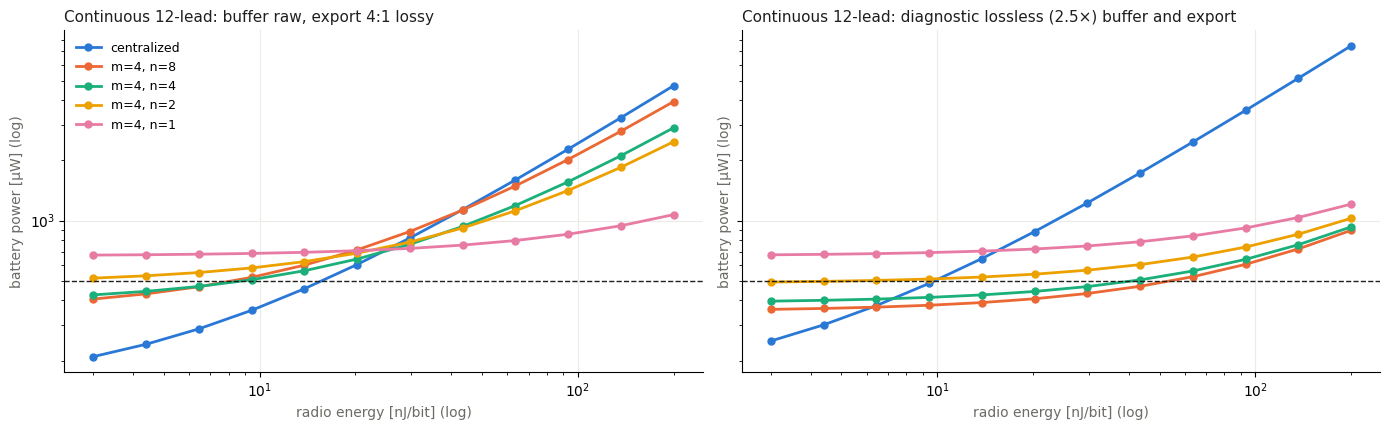

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, lossless, title in [(axes[0], False, 'buffer raw, export 4:1 lossy'), (axes[1], True, 'diagnostic lossless (2.5×) buffer and export')]:
    for k, (lbl, *_) in enumerate(ARCH):
        ys = [tot(lbl, pw.P(schedule='cont12L', E_tx_ble=e, diag_lossless=lossless)) for e in EB]
        ax.plot(EB, ys, color=HUES[k], lw=2, marker='o', ms=5, label=lbl)
    ax.axhline(p0['P_budget'] * 1e3, color=INK, lw=1, ls='--')
    ax.set_xscale('log'); ax.set_yscale('log')
    style(ax, f'Continuous 12-lead: {title}', 'radio energy [nJ/bit] (log)', 'battery power [µW] (log)')
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig('radio_energy_cont12L.png', dpi=160); plt.show()

## Breakeven radio energy: above it, distribution wins

In [3]:
def breakeven(**kw):
    lo, hi = 3.0, 200.0
    f = lambda e: margin(pw.P(E_tx_ble=e, **kw))[0] - 1
    if f(lo) > 0: return '< 3'
    if f(hi) < 0: return '> 200'
    for _ in range(25):
        mid = np.sqrt(lo * hi)
        lo, hi = (mid, hi) if f(mid) < 0 else (lo, mid)
    return f"{np.sqrt(lo*hi):.0f}"
rows = []
for S in [16, 32, 64]:
    for T in [5, 10, 20]:
        for lossless in [False, True]:
            rows.append(dict(SRAM_kB=S, T_win_12L_s=T, diag_lossless=lossless,
                             breakeven_nJ_per_bit=breakeven(schedule='cont12L', sram_cap_kB=S, T_win_12L=T, diag_lossless=lossless)))
BE = pd.DataFrame(rows); BE.pivot_table(index=['SRAM_kB', 'T_win_12L_s'], columns='diag_lossless', values='breakeven_nJ_per_bit', aggfunc='first')

diag_lossless        False  True 
SRAM_kB T_win_12L_s              
16      5               47      7
        10           > 200     14
        20           > 200     28
32      5               12  > 200
        10              24      6
        20              49     10
64      5            > 200  > 200
        10              13  > 200
        20              25      6

## Regime map: radio energy × chiplet SRAM (continuous 12-lead, 10 s window)

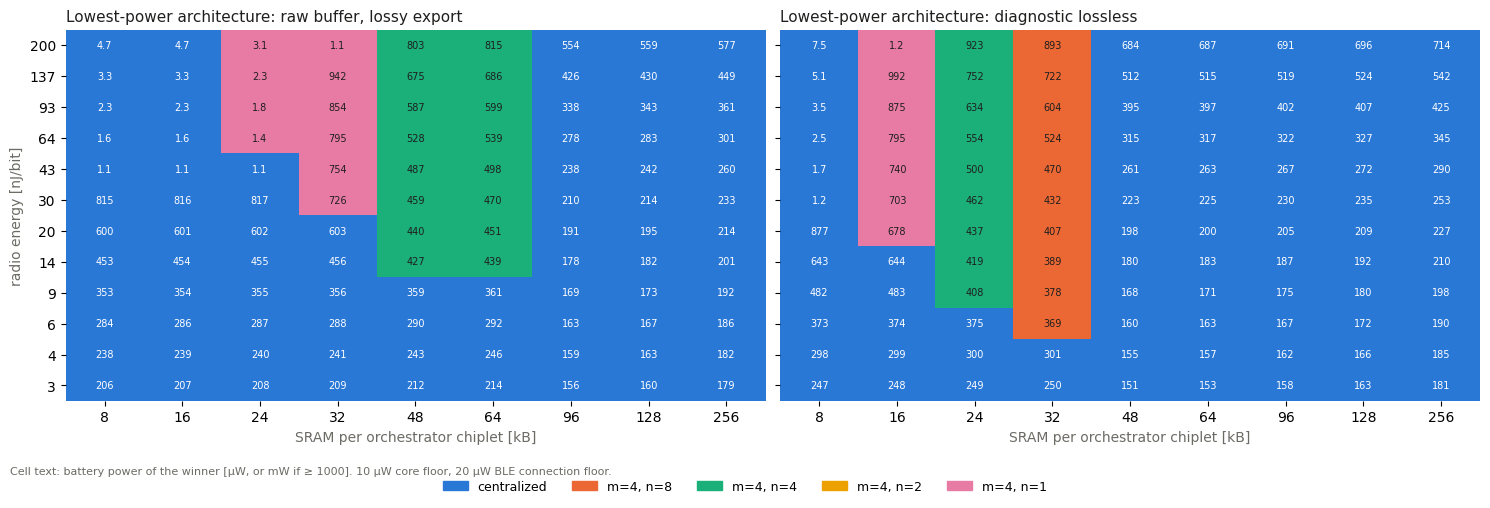

In [4]:
Ss = [8, 16, 24, 32, 48, 64, 96, 128, 256]
CATS = [a[0] for a in ARCH]
COL = HUES[:len(CATS)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, lossless in zip(axes, [False, True]):
    Z = np.zeros((len(EB), len(Ss)), int); PWm = np.zeros_like(Z, dtype=float)
    for i, e in enumerate(EB):
        for j, S in enumerate(Ss):
            pp = pw.P(schedule='cont12L', E_tx_ble=e, sram_cap_kB=S, diag_lossless=lossless)
            vals = {lbl: tot(lbl, pp) for lbl in CATS}
            w = min(vals, key=vals.get); Z[i, j] = CATS.index(w); PWm[i, j] = vals[w]
    ax.imshow(Z, cmap=ListedColormap(COL), vmin=-0.5, vmax=len(CATS) - 0.5, origin='lower', aspect='auto')
    for i in range(len(EB)):
        for j in range(len(Ss)):
            v = PWm[i, j]
            ax.text(j, i, f"{v/1000:.1f}" if v >= 1000 else f"{v:.0f}", ha='center', va='center', fontsize=7,
                    color='white' if Z[i, j] == 0 else INK)
    ax.set_xticks(range(len(Ss)), Ss); ax.set_yticks(range(len(EB)), [f"{e:.0f}" for e in EB])
    ax.set_xlabel('SRAM per orchestrator chiplet [kB]', color=MUTED)
    ax.set_title('Lowest-power architecture: ' + ('diagnostic lossless' if lossless else 'raw buffer, lossy export'), loc='left', fontsize=11, color=INK)
    for s_ in ax.spines.values(): s_.set_visible(False)
axes[0].set_ylabel('radio energy [nJ/bit]', color=MUTED)
fig.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in COL], CATS, frameon=False, fontsize=9, ncol=5, loc='lower center', bbox_to_anchor=(0.5, -0.02))
fig.text(0.01, 0.04, 'Cell text: battery power of the winner [µW, or mW if ≥ 1000]. 10 µW core floor, 20 µW BLE connection floor.', fontsize=8, color=MUTED)
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.savefig('radio_regime_map.png', dpi=160, bbox_inches='tight'); plt.show()

## Other schedules vs. radio energy

In [5]:
s146 = geo.build_layout(g, 'ML', int(p0['spares_per_site']), grid_pitch=5); D146 = geo.dist_matrix(g, s146); h146 = geo.central_hub(g, s146)
PT146 = {lbl: geo.build_point(g, s146, D146, (len(s146) if m == N else m), (len(s146) if n == N else n), 'mesh', 'mesh', h146) for lbl, m, n in ARCH}
rows = []
for e in [3, 10, 30, 100, 200]:
    for sch, kw, S, DD, pts in [('default', {}, sites, D, PT),
                                ('sleepBSPM, N=146, stream, 60 s, templates only', dict(schedule='sleepBSPM', bspm_analysis='stream', T_win_bspm=60, p_abnormal_bspm=0.0), s146, D146, PT146)]:
        mg, best, pc, pd_ = margin(pw.P(E_tx_ble=e, **kw), S=S, DD=DD, pts=pts)
        rows.append(dict(E_nJ_b=e, schedule=sch, centralized_uW=round(pc), best_distributed=best, distributed_uW=round(pd_), margin=round(mg, 2)))
pd.DataFrame(rows)

,E_nJ_b,schedule,centralized_uW,best_distributed,distributed_uW,margin
0,3,default,69,"m=4, n=8",141,0.49
1,3,"sleepBSPM, N=146, stream, 60 s, templates only",816,"m=4, n=4",952,0.86
2,10,default,70,"m=4, n=8",142,0.50
3,10,"sleepBSPM, N=146, stream, 60 s, templates only",1696,"m=4, n=4",988,1.72
4,30,default,74,"m=4, n=8",145,0.51
5,30,"sleepBSPM, N=146, stream, 60 s, templates only",4212,"m=4, n=4",1090,3.86
6,100,default,85,"m=4, n=8",155,0.55
7,100,"sleepBSPM, N=146, stream, 60 s, templates only",13015,"m=4, n=4",1446,9.00
8,200,default,102,"m=4, n=8",170,0.60
9,200,"sleepBSPM, N=146, stream, 60 s, templates only",25592,"m=4, n=4",1954,13.10


## Flip sensitivity: which assumptions can change the architecture choice?

Each parameter is swept from its logged low to its logged high, with everything else at baseline, in three scenarios:
* **A:** continuous 12-lead, 32 kB, 10 s window, 200 nJ/b (baseline: distributed wins)
* **B:** the same at 30 nJ/b (close to the crossover)
* **C:** the default schedule (baseline: centralized wins)

A parameter **flips** the decision if the margin crosses 1 within its range.

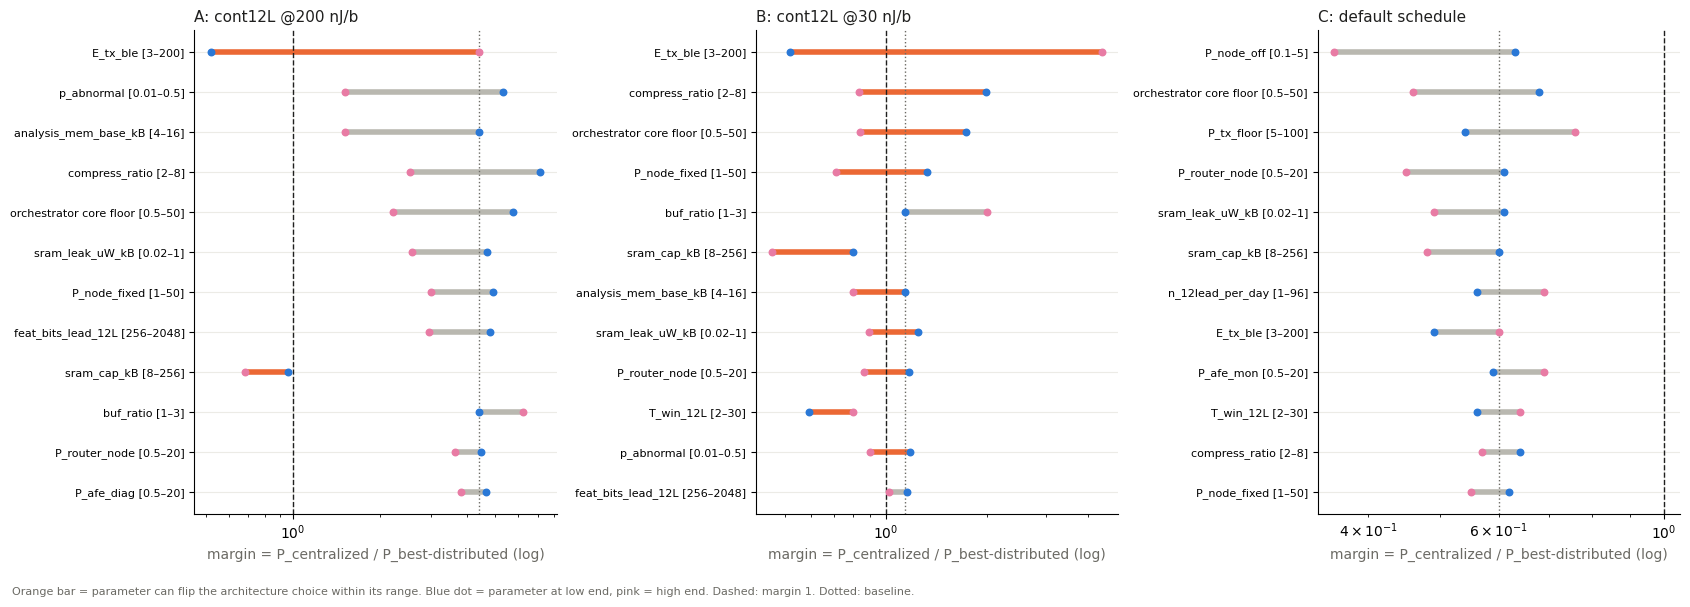

,scenario,param,low,high,margin_low,margin_base,margin_high,flips
0,A: cont12L @200 nJ/b,E_tx_ble,3.00,200.0,0.52,4.40,4.40,True
4,A: cont12L @200 nJ/b,T_win_12L,2.00,30.0,0.85,4.40,0.96,True
2,A: cont12L @200 nJ/b,sram_cap_kB,8.00,256.0,0.96,4.40,0.68,True
23,B: cont12L @30 nJ/b,E_tx_ble,3.00,200.0,0.52,1.14,4.40,True
32,B: cont12L @30 nJ/b,P_node_fixed,1.00,50.0,1.33,1.14,0.71,True
33,B: cont12L @30 nJ/b,P_router_node,0.50,20.0,1.17,1.14,0.86,True
27,B: cont12L @30 nJ/b,T_win_12L,2.00,30.0,0.59,1.14,0.80,True
39,B: cont12L @30 nJ/b,analysis_mem_base_kB,4.00,16.0,1.14,1.14,0.80,True
31,B: cont12L @30 nJ/b,compress_ratio,2.00,8.0,1.99,1.14,0.83,True
45,B: cont12L @30 nJ/b,orchestrator core floor,0.50,50.0,1.73,1.14,0.84,True


In [6]:
t = params.table()
names = ['E_tx_ble', 'P_tx_floor', 'sram_cap_kB', 'sram_leak_uW_kB', 'T_win_12L', 'buf_ratio', 'p_abnormal', 'feat_bits_lead_12L',
         'compress_ratio', 'P_node_fixed', 'P_router_node', 'P_node_off', 'P_afe_diag', 'P_afe_mon', 'W_lead', 'eta_pmu',
         'analysis_mem_base_kB', 'yarn_C', 'n_12lead_per_day', 'hr_hz', 'f_cap_MHz', 'lossless_ratio']
SC = {'A: cont12L @200 nJ/b': dict(schedule='cont12L'), 'B: cont12L @30 nJ/b': dict(schedule='cont12L', E_tx_ble=30), 'C: default schedule': {}}
rows = []
for sc, kw in SC.items():
    base = margin(pw.P(**kw))[0]
    for nm in names:
        lo, hi = t.loc[nm, 'low'], t.loc[nm, 'high']
        if lo != lo or hi != hi:
            continue
        mlo = margin(pw.P(**{**kw, nm: lo}))[0]; mhi = margin(pw.P(**{**kw, nm: hi}))[0]
        flips = (min(mlo, mhi, base) < 1) and (max(mlo, mhi, base) > 1)
        rows.append(dict(scenario=sc, param=nm, low=lo, high=hi, margin_low=round(mlo, 2), margin_base=round(base, 2),
                         margin_high=round(mhi, 2), span=abs(np.log(mhi) - np.log(mlo)), flips=flips))
    # orchestrator core floor is an argument, not a table parameter
    flo = margin(pw.P(**kw), floor=0.5e-6)[0]; fhi = margin(pw.P(**kw), floor=50e-6)[0]
    rows.append(dict(scenario=sc, param='orchestrator core floor', low=0.5, high=50, margin_low=round(flo, 2), margin_base=round(base, 2),
                     margin_high=round(fhi, 2), span=abs(np.log(fhi) - np.log(flo)), flips=(min(flo, fhi, base) < 1) and (max(flo, fhi, base) > 1)))
F = pd.DataFrame(rows); F.to_csv('flip_sensitivity.csv', index=False)
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)
for ax, sc in zip(axes, SC):
    sub = F[F.scenario == sc].sort_values('span').tail(12)
    y = np.arange(len(sub))
    for i, r in enumerate(sub.itertuples()):
        ax.plot([r.margin_low, r.margin_high], [i, i], color=HUES[1] if r.flips else '#b9b8b0', lw=4, solid_capstyle='butt')
        ax.scatter([r.margin_low], [i], color=HUES[0], s=22, zorder=3); ax.scatter([r.margin_high], [i], color=HUES[4], s=22, zorder=3)
    ax.axvline(1, color=INK, lw=1, ls='--'); ax.axvline(sub.margin_base.iloc[0], color=MUTED, lw=1, ls=':')
    ax.set_xscale('log'); ax.set_yticks(y, [f"{r.param} [{r.low:g}–{r.high:g}]" for r in sub.itertuples()], fontsize=8)
    style(ax, sc, 'margin = P_centralized / P_best-distributed (log)', '')
fig.text(0.01, 0.0, 'Orange bar = parameter can flip the architecture choice within its range. Blue dot = parameter at low end, pink = high end. Dashed: margin 1. Dotted: baseline.', fontsize=8, color=MUTED)
plt.tight_layout(rect=(0, 0.03, 1, 1)); plt.savefig('flip_sensitivity.png', dpi=160); plt.show()
F[F.flips].drop(columns='span').sort_values(['scenario', 'param'])

## Findings

1. **The intuition holds: an expensive radio favours distribution, and a cheap one favours centralized.** For continuous 12-lead with 32 kB chiplets and a 10 s window:
   * the crossover is about **24 nJ/b** with raw buffers and lossy export, and about **6 nJ/b** with a diagnostic-lossless record;
   * at 3 nJ/b, centralized streaming (209 µW) beats every distributed design (≥ 406 µW);
   * at 200 nJ/b, distribution wins by 4.4×, or by about 8× when lossless.
   * The breakeven moves with SRAM and window: at 16–64 kB and 5–20 s it ranges from about 12 to 49 nJ/b (lossy), from 6 to 28 nJ/b (lossless), or there is no crossover at all when one design fits outright.
2. **On-body processing is a hedge against radio energy.** The reported range (3–200 nJ/b) straddles the crossover. At an effective radio cost of a few nJ/b, the transmit argument for distribution disappears for 12-lead, and the case has to rest on pads and memory scaling (notebook 06).
3. **The overnight BSPM shirt (N ≈ 146) breaks even at about 4–5 nJ/b.** Above about 10 nJ/b, distribution is 1.7–13× better. Separately, centralized is pad-infeasible at this N.
4. **The default schedule is centralized at every radio energy** (margin 0.49–0.60), and no parameter flips it. But at N = 74, a centralized chiplet needs 76 IO pads, so the realistic default-schedule winner is the best distributed design: m = 8, n = 4 at 141–170 µW.
5. **The weak links are the parameters that can flip the decision:**
   * **Expensive radio (200 nJ/b):** the decision is robust. Only radio energy, the analysis window and SRAM size flip it.
   * **Near the crossover (30 nJ/b):** many invented numbers flip it: compression ratio, orchestrator core floor, sensor-node overhead, SRAM cap and leakage, analysis base memory, router idle and abnormal fraction.
   * The model's answer is therefore reliable away from the crossover and assumption-driven near it. Report the crossover band rather than a point answer.
